# 1. Import and Hardware Setup

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset

import os
import math
import random
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

!pip install tqdm -q
from tqdm.auto import tqdm

In [16]:
DATA_PATH = './data'

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print(device)

cuda


# 2. Hyperparamter

In [ ]:
BATCH_SIZE = 128
IMG_SIZE = 128
IN_CHANNELS = 3
PATCH_SIZE = 16  # Each patch is 16x16 pixels

LR = 1.5e-4
EPOCHS = 100
SEED = 42
NUM_CLASSES = 50

# ----- MAE Masking -----
MASK_RATIO = 0.75  

# ----- ViT Encoder -----
ENC_EMBED_DIM = 768
ENC_DEPTH = 12
ENC_NUM_HEADS = 12

# ----- MAE Decoder -----
DEC_EMBED_DIM = 512
DEC_DEPTH = 8
DEC_NUM_HEADS = 16

# ----- Common -----
MLP_RATIO = 4.0
DROP_RATE = 0.0  # No dropout during MAE pre-training

NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2
print(f"Number of patches: {NUM_PATCHES}")
print(f"Visible patches: {int(NUM_PATCHES * (1 - MASK_RATIO))}")
print(f"Masked patches: {int(NUM_PATCHES * MASK_RATIO)}")

Number of patches: 64
Visible patches: 16
Masked patches: 48


# 3. Data Preparation

In [18]:
def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception:
        pass

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

In [19]:
# MAE pre-training uses minimal augmentation.
# The masking itself acts as a strong regularizer.
train_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.RandomCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
    ]
)

# Apply seed
set_seed(SEED)
train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

filtered_indices = [i for i, label in enumerate(dummy_data._labels) if label < NUM_CLASSES]

train_size = int(0.8 * len(filtered_indices))
val_size = len(filtered_indices) - train_size
split_generator = torch.Generator().manual_seed(SEED)

filtered_dummy_data = Subset(dummy_data, filtered_indices)
train_tmp_subset, val_tmp_subset = random_split(
    filtered_dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = [filtered_indices[i] for i in train_tmp_subset.indices]
val_indices = [filtered_indices[i] for i in val_tmp_subset.indices]

train_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=train_transform,
)

val_dataset = datasets.Food101(
    root=DATA_PATH,
    split="train",
    download=False,
    transform=val_transform,
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)


dummy_test_dataset = datasets.Food101(root=DATA_PATH, split="test", download=True)
test_filterd_indices = [
    i for i, label in enumerate(dummy_test_dataset._labels) if label < NUM_CLASSES
]

test_dataset_full = datasets.Food101(
    root=DATA_PATH,
    split="test",
    download=False,
    transform=val_transform,
)
test_dataset = Subset(test_dataset_full, test_filterd_indices)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True,
    prefetch_factor=10,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)


# 4. Model Architecture

In [ ]:
# ============================================================
# Patch Embedding
# ============================================================
class PatchEmbed(nn.Module):
    """Split image into non-overlapping patches and project to embedding dim."""

    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        # Use Conv2d as efficient patch projection
        self.proj = nn.Conv2d(
            in_channels,
            embed_dim,
            kernel_size=patch_size,
            stride=patch_size,
        )

    def forward(self, x):
        # x: (B, C, H, W) -> (B, num_patches, embed_dim)
        x = self.proj(x)  # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)  # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


# ============================================================
# Transformer Building Blocks
# ============================================================
class MLP(nn.Module):
    """Feed-Forward Network used in each Transformer block."""

    def __init__(self, in_features, hidden_features, drop_rate=0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.drop = nn.Dropout(drop_rate)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class TransformerBlock(nn.Module):
    """Standard Transformer encoder block: LN -> MSA -> residual -> LN -> MLP -> residual."""

    def __init__(self, embed_dim, num_heads, mlp_ratio=4.0, drop_rate=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(
            embed_dim,
            num_heads,
            dropout=drop_rate,
            batch_first=True,
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(
            in_features=embed_dim,
            hidden_features=int(embed_dim * mlp_ratio),
            drop_rate=drop_rate,
        )

    def forward(self, x):
        # Pre-norm architecture
        normed = self.norm1(x)
        x = x + self.attn(normed, normed, normed, need_weights=False)[0]
        x = x + self.mlp(self.norm2(x))
        return x


# ============================================================
# Positional Embedding Utilities
# ============================================================
def get_2d_sincos_pos_embed(embed_dim, grid_size):
    """
    Generate 2D sinusoidal positional embeddings (He et al. 2022).

    Args:
        embed_dim: Embedding dimension (must be divisible by 2).
        grid_size: Number of patches along one spatial dimension.

    Returns:
        pos_embed: (grid_size*grid_size, embed_dim) numpy array.
    """
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid = np.meshgrid(grid_w, grid_h)  # (2, grid_size, grid_size)
    grid = np.stack(grid, axis=0).reshape(2, -1)  # (2, grid_size^2)

    half_dim = embed_dim // 2
    pos_embed = np.zeros((grid.shape[1], embed_dim))

    for i in range(2):  # For height and width
        omega = np.arange(half_dim // 2, dtype=np.float64) / (half_dim // 2)
        omega = 1.0 / (10000.0**omega)
        out = np.outer(grid[i], omega)  # (grid_size^2, half_dim//2)
        pos_embed[:, i * (half_dim) : i * (half_dim) + half_dim // 2] = np.sin(out)
        pos_embed[:, i * (half_dim) + half_dim // 2 : (i + 1) * half_dim] = np.cos(out)

    return pos_embed.astype(np.float32)


# ============================================================
# MAE Encoder
# ============================================================
class MAE_Encoder(nn.Module):
    """
    MAE Encoder: Processes only visible (unmasked) patches.

    Key idea from He et al. 2022:
    - Randomly mask a large portion (e.g. 75%) of patches
    - Only feed visible patches into the ViT encoder
    - This makes the encoder much more efficient
    """

    def __init__(
        self,
        img_size,
        patch_size,
        in_channels,
        embed_dim,
        depth,
        num_heads,
        mlp_ratio,
        drop_rate,
    ):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches

        # Fixed sinusoidal positional embedding (not learnable)
        pos_embed = get_2d_sincos_pos_embed(embed_dim, int(num_patches**0.5))
        self.pos_embed = nn.Parameter(
            torch.from_numpy(pos_embed).unsqueeze(0),  # (1, N, D)
            requires_grad=False,
        )

        # Transformer encoder blocks
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(embed_dim, num_heads, mlp_ratio, drop_rate)
                for _ in range(depth)
            ]
        )
        self.norm = nn.LayerNorm(embed_dim)

    def random_masking(self, x, mask_ratio):
        """
        Perform random masking by shuffling patch indices.

        Args:
            x: (B, N, D) patch embeddings.
            mask_ratio: Fraction of patches to mask.

        Returns:
            x_visible: (B, N_visible, D) visible patch embeddings.
            mask: (B, N) binary mask (1 = masked, 0 = visible).
            ids_restore: (B, N) indices to unshuffle patches.
        """
        B, N, D = x.shape
        num_keep = int(N * (1 - mask_ratio))

        # Generate random noise for shuffling
        noise = torch.rand(B, N, device=x.device)

        # Sort noise to get shuffled indices
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)

        # Keep only the first num_keep patches (lowest noise values)
        ids_keep = ids_shuffle[:, :num_keep]
        x_visible = torch.gather(
            x, dim=1, index=ids_keep.unsqueeze(-1).expand(-1, -1, D)
        )

        # Build binary mask: 0 = visible, 1 = masked
        mask = torch.ones(B, N, device=x.device)
        mask[:, :num_keep] = 0
        mask = torch.gather(mask, dim=1, index=ids_restore)

        return x_visible, mask, ids_restore

    def forward(self, x, mask_ratio):
        """
        Forward pass with masking.

        Args:
            x: (B, C, H, W) input images.
            mask_ratio: Fraction of patches to mask.

        Returns:
            x: (B, N_visible, D) encoded visible patches.
            mask: (B, N) binary mask.
            ids_restore: (B, N) indices to restore original order.
        """
        # Patchify and add positional embedding
        x = self.patch_embed(x)  # (B, N, D)
        x = x + self.pos_embed  # Add position info

        # Apply random masking
        x, mask, ids_restore = self.random_masking(x, mask_ratio)

        # Encode only visible patches
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)

        return x, mask, ids_restore

    def forward_features(self, x):
        """
        Encode ALL patches without masking (for downstream tasks / t-SNE).

        Args:
            x: (B, C, H, W) input images.

        Returns:
            x: (B, N, D) encoded all patches.
        """
        x = self.patch_embed(x)
        x = x + self.pos_embed

        for block in self.blocks:
            x = block(x)
        x = self.norm(x)

        return x


# ============================================================
# MAE Decoder
# ============================================================
class MAE_Decoder(nn.Module):
    """
    MAE Decoder: Reconstructs masked patches from visible patch encodings.

    The decoder is intentionally lightweight compared to the encoder.
    It receives the encoded visible patches plus learnable mask tokens,
    and predicts pixel values for each patch.
    """

    def __init__(
        self,
        num_patches,
        patch_size,
        in_channels,
        enc_embed_dim,
        dec_embed_dim,
        dec_depth,
        dec_num_heads,
        mlp_ratio,
        drop_rate,
    ):
        super().__init__()

        # Project encoder output to decoder dimension
        self.decoder_embed = nn.Linear(enc_embed_dim, dec_embed_dim)

        # Learnable mask token (shared for all masked positions)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dec_embed_dim))
        nn.init.normal_(self.mask_token, std=0.02)

        # Fixed sinusoidal positional embedding for decoder
        dec_pos_embed = get_2d_sincos_pos_embed(dec_embed_dim, int(num_patches**0.5))
        self.decoder_pos_embed = nn.Parameter(
            torch.from_numpy(dec_pos_embed).unsqueeze(0),
            requires_grad=False,
        )

        # Transformer decoder blocks
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(dec_embed_dim, dec_num_heads, mlp_ratio, drop_rate)
                for _ in range(dec_depth)
            ]
        )
        self.norm = nn.LayerNorm(dec_embed_dim)

        # Predict pixel values for each patch
        self.head = nn.Linear(dec_embed_dim, patch_size * patch_size * in_channels)

    def forward(self, x, ids_restore):
        """
        Args:
            x: (B, N_visible, enc_embed_dim) encoded visible patches.
            ids_restore: (B, N) indices to unshuffle to original order.

        Returns:
            pred: (B, N, patch_size^2 * C) predicted pixel values per patch.
        """
        B, N_vis, _ = x.shape
        N = ids_restore.shape[1]  # Total number of patches

        # Project encoder output to decoder dimension
        x = self.decoder_embed(x)  # (B, N_vis, dec_embed_dim)

        # Append mask tokens for masked positions
        num_masked = N - N_vis
        mask_tokens = self.mask_token.expand(B, num_masked, -1)
        x = torch.cat([x, mask_tokens], dim=1)  # (B, N, dec_embed_dim)

        # Unshuffle to original patch order
        x = torch.gather(
            x,
            dim=1,
            index=ids_restore.unsqueeze(-1).expand(-1, -1, x.shape[2]),
        )

        # Add positional embedding and process through decoder
        x = x + self.decoder_pos_embed
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)

        # Predict pixel values
        pred = self.head(x)  # (B, N, patch_size^2 * C)
        return pred


# ============================================================
# Full MAE Model
# ============================================================
class MaskedAutoencoder(nn.Module):
    """
    Masked Autoencoder (MAE) with Vision Transformer.

    Architecture overview (He et al. 2022):
    1. Split image into patches
    2. Randomly mask 75% of patches
    3. Encode only visible patches with a ViT encoder
    4. Decode all patches (visible + mask tokens) with a lightweight decoder
    5. Compute MSE loss only on masked patches (in pixel space)

    The per-patch normalization of targets improves representation quality.
    """

    def __init__(
        self,
        img_size,
        patch_size,
        in_channels,
        enc_embed_dim,
        enc_depth,
        enc_num_heads,
        dec_embed_dim,
        dec_depth,
        dec_num_heads,
        mlp_ratio=4.0,
        drop_rate=0.0,
        norm_pix_loss=True,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.norm_pix_loss = norm_pix_loss
        num_patches = (img_size // patch_size) ** 2

        # Encoder
        self.encoder = MAE_Encoder(
            img_size,
            patch_size,
            in_channels,
            enc_embed_dim,
            enc_depth,
            enc_num_heads,
            mlp_ratio,
            drop_rate,
        )

        # Decoder
        self.decoder = MAE_Decoder(
            num_patches,
            patch_size,
            in_channels,
            enc_embed_dim,
            dec_embed_dim,
            dec_depth,
            dec_num_heads,
            mlp_ratio,
            drop_rate,
        )

    def patchify(self, imgs):
        """
        Convert images to patch sequences.

        Args:
            imgs: (B, C, H, W)

        Returns:
            patches: (B, N, patch_size^2 * C)
        """
        P = self.patch_size
        C = self.in_channels
        B, _, H, W = imgs.shape
        h, w = H // P, W // P

        x = imgs.reshape(B, C, h, P, w, P)
        x = x.permute(0, 2, 4, 3, 5, 1)  # (B, h, w, P, P, C)
        x = x.reshape(B, h * w, P * P * C)
        return x

    def unpatchify(self, patches):
        """
        Convert patch sequences back to images.

        Args:
            patches: (B, N, patch_size^2 * C)

        Returns:
            imgs: (B, C, H, W)
        """
        P = self.patch_size
        C = self.in_channels
        B = patches.shape[0]
        h = w = int(patches.shape[1] ** 0.5)

        x = patches.reshape(B, h, w, P, P, C)
        x = x.permute(0, 5, 1, 3, 2, 4)  # (B, C, h, P, w, P)
        x = x.reshape(B, C, h * P, w * P)
        return x

    def forward_loss(self, imgs, pred, mask):
        """
        Compute MSE loss only on masked patches.

        Args:
            imgs: (B, C, H, W) original images.
            pred: (B, N, patch_size^2 * C) predicted pixel values.
            mask: (B, N) binary mask (1 = masked, 0 = visible).

        Returns:
            loss: Scalar MSE loss computed on masked patches only.
        """
        target = self.patchify(imgs)  # (B, N, P^2 * C)

        # Per-patch normalization of targets (He et al. 2022)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1e-6).sqrt()

        # MSE per patch
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # Mean over pixel dimension -> (B, N)

        # Average loss only over masked patches
        loss = (loss * mask).sum() / mask.sum()
        return loss

    def forward(self, imgs, mask_ratio=0.75):
        """
        Full MAE forward pass.

        Args:
            imgs: (B, C, H, W) input images.
            mask_ratio: Fraction of patches to mask.

        Returns:
            loss: Reconstruction loss on masked patches.
            pred: (B, N, P^2 * C) predicted pixel values.
            mask: (B, N) binary mask.
        """
        # Encode visible patches
        latent, mask, ids_restore = self.encoder(imgs, mask_ratio)

        # Decode all patches
        pred = self.decoder(latent, ids_restore)

        # Compute loss on masked patches
        loss = self.forward_loss(imgs, pred, mask)

        return loss, pred, mask

In [21]:
model = MaskedAutoencoder(
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=IN_CHANNELS,
    enc_embed_dim=ENC_EMBED_DIM,
    enc_depth=ENC_DEPTH,
    enc_num_heads=ENC_NUM_HEADS,
    dec_embed_dim=DEC_EMBED_DIM,
    dec_depth=DEC_DEPTH,
    dec_num_heads=DEC_NUM_HEADS,
    mlp_ratio=MLP_RATIO,
    drop_rate=DROP_RATE,
    norm_pix_loss=True,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params / 1e6:.2f}M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f}M")

Total parameters: 111.74M
Trainable parameters: 111.65M


# 5. Train Preparation

In [22]:
class EarlyStopping:
    def __init__(
        self, patience=10, delta=0, verbose=False, save_path="best_checkpoint.pth"
    ):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path

        self.early_stop = False
        self.counter = 0
        self.best_loss = None
    
    def __call__(self, model, val_loss):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        
        # 2. If the loss didnt decrease as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        
        # 3. The loss decreased properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ...")
        state_dict = (
            model.module.state_dict()
            if hasattr(model, "module")
            else model.state_dict()
        )
        torch.save(state_dict, self.save_path)



In [23]:
# No separate criterion needed — loss is computed inside the MAE model.
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)
scaler = torch.amp.GradScaler(device=device)

In [24]:
def train(model, loader, optimizer, scaler, mask_ratio=MASK_RATIO):
    """Run one training epoch for MAE."""
    model.train()
    train_loss = 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for images, _ in loop:
        images = images.to(device)
        optimizer.zero_grad()

        with torch.autocast(device_type=device.type):
            loss, _, _ = model(images, mask_ratio=mask_ratio)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.detach() * images.size(0)

    return train_loss.item() / len(loader.dataset)


def validate(model, loader, mask_ratio=MASK_RATIO):
    """Run one validation epoch for MAE."""
    model.eval()
    val_loss = 0.0
    loop = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, _ in loop:
            images = images.to(device)

            with torch.autocast(device_type=device.type):
                loss, _, _ = model(images, mask_ratio=mask_ratio)

            val_loss += loss.detach() * images.size(0)

    return val_loss.item() / len(loader.dataset)

# 6. Training

In [25]:
early_stopping = EarlyStopping(patience=5, save_path="best_mae_checkpoint.pth")
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    train_loss = train(model, train_loader, optimizer, scaler)
    val_loss = validate(model, val_loader)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    early_stopping(model, val_loss)
    if early_stopping.early_stop:
        print("Early stopping triggered")
        break

# Load best model for evaluation
model.load_state_dict(torch.load("best_mae_checkpoint.pth", weights_only=True, map_location=device))

Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 1/100: Train Loss: 0.747222 | Val Loss: 0.720104


Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

...

Training:   0%|          | 0/235 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 70/100: Train Loss: 0.442325 | Val Loss: 0.438219


Training:   0%|          | 0/235 [00:00<?, ?it/s]

KeyboardInterrupt: 

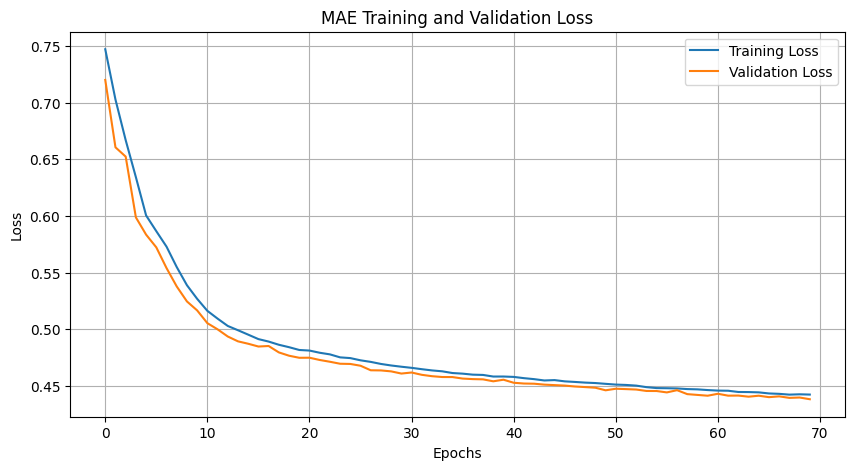

In [26]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('MAE Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# 7. Results

Visualizing MAE reconstruction...


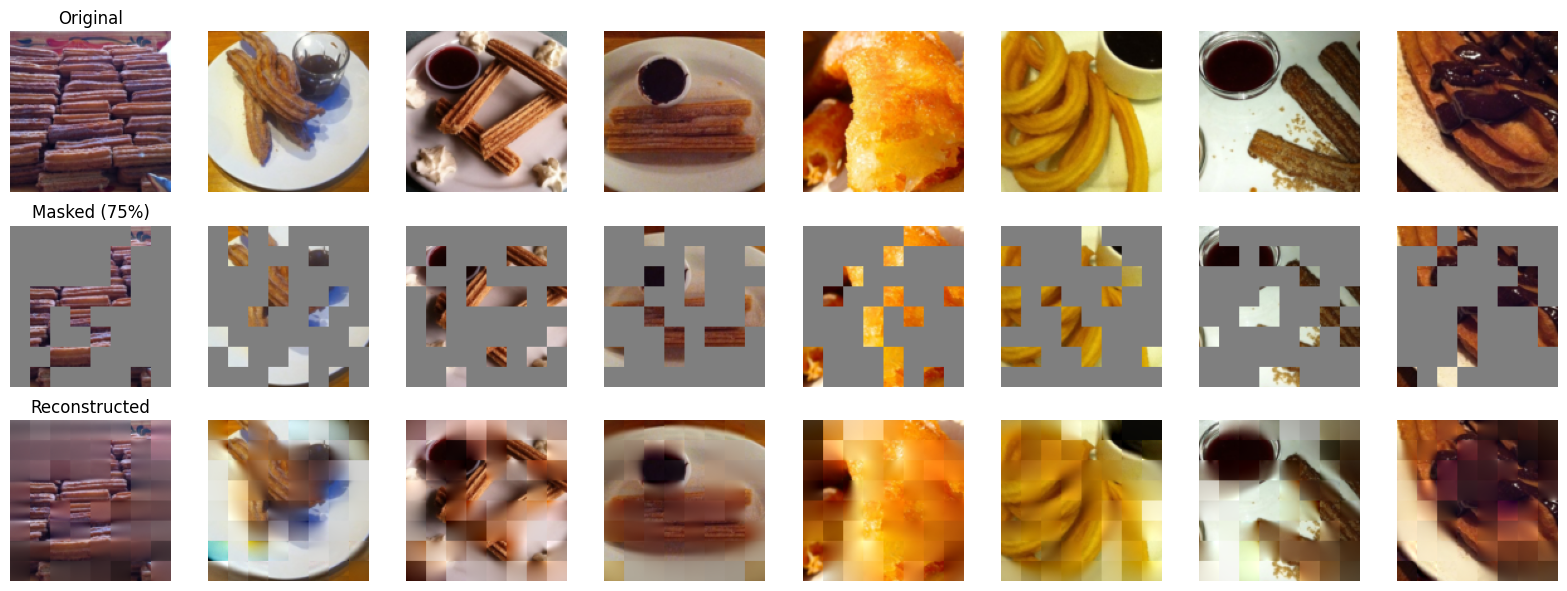

In [27]:
def visualize_mae_reconstruction(model, test_loader, num_images=8, mask_ratio=MASK_RATIO):
    """
    Visualize MAE reconstruction: Original | Masked | Reconstructed.

    Shows which patches were masked and how well the model reconstructs them.
    """
    model.eval()
    dataiter = iter(test_loader)
    images, _ = next(dataiter)
    images = images[:num_images].to(device)

    with torch.no_grad():
        with torch.autocast(device_type=device.type):
            loss, pred, mask = model(images, mask_ratio=mask_ratio)

    # --- Denormalize predictions if norm_pix_loss was used ---
    # The model predicts normalized patch values (zero mean, unit variance per patch).
    # To visualize correctly, we must reverse this normalization using
    # the original patch statistics.
    pred_float = pred.float()
    if model.norm_pix_loss:
        target_patches = model.patchify(images)  # (B, N, P^2 * C)
        patch_mean = target_patches.mean(dim=-1, keepdim=True)
        patch_var = target_patches.var(dim=-1, keepdim=True)
        # Reverse: pred_denorm = pred * sqrt(var + eps) + mean
        pred_float = pred_float * (patch_var + 1e-6).sqrt() + patch_mean

    # Unpatchify predictions to image space
    pred_imgs = model.unpatchify(pred_float).clamp(0, 1).cpu()
    images_cpu = images.cpu()
    mask_cpu = mask.cpu()  # (B, N)

    P = model.patch_size
    C = model.in_channels
    _, _, H, W = images_cpu.shape
    h, w = H // P, W // P

    # --- Build masked view ---
    # Expand mask to pixel-level: mask_cpu (B, N) -> (B, C, H, W)
    # FIX: Must permute before reshape to correctly form 2D patch blocks
    # instead of horizontal stripes.
    mask_img = mask_cpu.reshape(-1, h, w)              # (B, h, w)
    mask_img = mask_img.unsqueeze(-1).unsqueeze(-1)     # (B, h, w, 1, 1)
    mask_img = mask_img.expand(-1, -1, -1, P, P)        # (B, h, w, P, P)
    mask_img = mask_img.permute(0, 1, 3, 2, 4)          # (B, h, P, w, P)  <-- FIX
    mask_img = mask_img.reshape(-1, h * P, w * P)        # (B, H, W)
    mask_img = mask_img.unsqueeze(1).expand(-1, C, -1, -1)  # (B, C, H, W)

    # Masked view: visible patches from original, masked patches as gray
    masked_view = images_cpu.clone()
    masked_view[mask_img == 1] = 0.5  # Gray for masked patches

    # --- Build composite reconstruction ---
    # Show original pixels for visible patches, predictions for masked patches
    composite = images_cpu.clone()
    composite[mask_img == 1] = pred_imgs[mask_img == 1]

    fig, axes = plt.subplots(3, num_images, figsize=(num_images * 2, 6))
    row_titles = ['Original', f'Masked ({int(mask_ratio*100)}%)', 'Reconstructed']

    for i in range(num_images):
        for row, data in enumerate([images_cpu, masked_view, composite]):
            ax = axes[row, i]
            img = np.transpose(data[i].numpy(), (1, 2, 0))
            ax.imshow(img)
            ax.axis('off')
            if i == 0:
                ax.set_title(row_titles[row])

    plt.tight_layout()
    plt.show()


# Show results
print("Visualizing MAE reconstruction...")
visualize_mae_reconstruction(model, test_loader, num_images=8)


# 8. Latent Space Analysis (t-SNE)

Starting t-SNE with 600 filtered images from 6 classes...


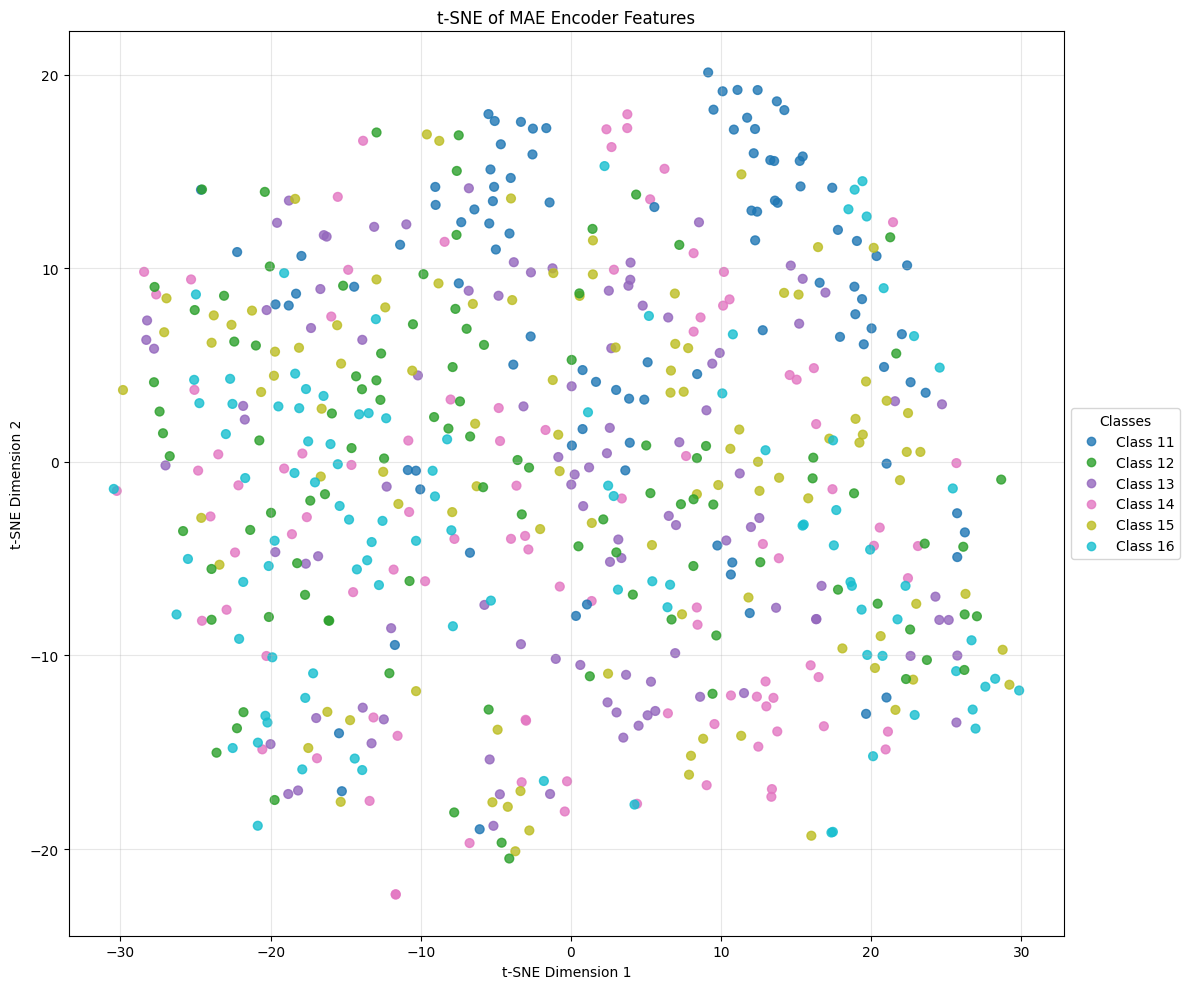

In [28]:
!pip install scikit-learn -q
from sklearn.manifold import TSNE


def visualize_tsne(
    model,
    dataloader,
    num_samples_per_class=100,
    target_classes=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
):
    """Visualize t-SNE of MAE encoder features (using all patches, no masking)."""
    model.eval()
    latents = []
    labels = []

    # Create a list of human-readable class names
    try:
        class_names = [dataloader.dataset.classes[i] for i in target_classes]
    except AttributeError:
        # Fallback
        class_names = [f"Class {i}" for i in target_classes]

    class_counts = {c: 0 for c in target_classes}

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(device)

            # Use forward_features (no masking) to get patch embeddings
            features = model.encoder.forward_features(images)  # (B, N, D)
            # Global average pooling over patch tokens
            latent = features.mean(dim=1)  # (B, D)

            # Filter the batch
            for i in range(len(targets)):
                target_idx = targets[i].item()
                if (
                    target_idx in target_classes
                    and class_counts[target_idx] < num_samples_per_class
                ):
                    latents.append(latent[i].cpu().numpy())
                    labels.append(target_classes.index(target_idx))
                    class_counts[target_idx] += 1

            if all(count >= num_samples_per_class for count in class_counts.values()):
                break

    latents = np.array(latents)
    labels = np.array(labels)

    print(f"Starting t-SNE with {len(latents)} filtered images from {len(target_classes)} classes...")
    tsne = TSNE(n_components=2, random_state=42, init="pca", learning_rate="auto")
    latents_2d = tsne.fit_transform(latents)

    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(
        latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap="tab10", alpha=0.8, s=40
    )

    handles, _ = scatter.legend_elements(prop="colors")
    plt.legend(
        handles,
        class_names,
        title="Classes",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
    )

    plt.title("t-SNE of MAE Encoder Features")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


visualize_tsne(model, test_loader, target_classes=[11, 12, 13, 14, 15, 16])
